# 05 - AG para RandomForest — Comparação com o HistGB

Na Fase 1, testamos 3 modelos: **LogisticRegression**, **RandomForest** e **HistGradientBoosting**.
O HistGB venceu no critério de recall/F2 operacional, mas o RandomForest chegou a
ROC-AUC maior (~0.72 no teste vs 0.58 do HistGB).

Este notebook aplica o AG ao **RandomForest**, otimizando o espaço de hiperparâmetros
específico desse modelo com o scorer no threshold operacional 0.40.

**Pergunta central:** o AG consegue extrair do RandomForest um desempenho
melhor do que o HistGB otimizado da Fase 1, aproveitando o AUC superior?

| Métrica | HistGB baseline | RF baseline (Fase 1) |
|---|---|---|
| ROC-AUC | 0.5773 | ~0.72 |
| Recall @0.40 | 0.9743 | — |
| F2 @0.40 | 0.3857 | — |

**Espaço de busca RF: 6 parâmetros | ~4.500 combinações**

`class_weight` é um gene do cromossomo — o AG escolhe entre `balanced`
e `balanced_subsample` (este último aplica o balanceamento por amostragem, não por pesos fixos).

In [1]:
import gc
import json
import math
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.utils.class_weight import compute_sample_weight

# path setup antes de qualquer import local
_SRC_DIR = Path('../src').resolve()
if str(_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(_SRC_DIR))

from pipeline import apply_scenario

In [2]:
SRC_DIR = Path('../src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

warnings.filterwarnings('ignore')

RANDOM_STATE          = 42
CV_SPLITS             = 3
MIN_RECALL_THRESHOLD  = 0.80
OPERATIONAL_THRESHOLD = 0.40
SCENARIO              = 'B'

DATA_DIR      = Path('../data')
METRICS_DIR   = Path('../results/metrics')
ARTIFACTS_DIR = Path('../results/artifacts')
FIGURES_DIR   = Path('../results/figures')

N_JOBS = max(1, (os.cpu_count() - 4) // 2)
print(f'CPUs disponíveis : {os.cpu_count()}')
print(f'N_JOBS (05)     : {N_JOBS}  — reserva 4 cores para uso pessoal')

CPUs disponíveis : 12
N_JOBS (05e)     : 4  — reserva 4 cores para uso pessoal


In [3]:
def load_scenario_data(scenario: str) -> tuple:
    X_train_full = pd.read_parquet(DATA_DIR / 'X_train.parquet')
    X_test_full  = pd.read_parquet(DATA_DIR / 'X_test.parquet')
    y_train = pd.read_parquet(DATA_DIR / 'y_train.parquet').iloc[:, 0]
    y_test  = pd.read_parquet(DATA_DIR / 'y_test.parquet').iloc[:, 0]
    X_train = apply_scenario(X_train_full, scenario)
    X_test  = apply_scenario(X_test_full,  scenario)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_scenario_data(SCENARIO)
print('X_train:', X_train.shape)

X_train: (562520, 26)


## Baselines: RF Fase 1 e HistGB Fase 1

Comparamos o AG-RF contra dois baselines:
1. **RF baseline** — melhor RandomForest da Fase 1 (cenário B, RandomizedSearch)
2. **HistGB baseline** — vencedor da Fase 1, ponto de referência clínico

In [4]:
METRIC_NAMES = ['recall', 'f2', 'precision', 'roc_auc', 'average_precision', 'brier']

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'threshold':         float(threshold),
        'recall':            recall_score(y_true, y_pred, zero_division=0),
        'f2':                fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'f1':                f1_score(y_true, y_pred, zero_division=0),
        'precision':         precision_score(y_true, y_pred, zero_division=0),
        'roc_auc':           roc_auc_score(y_true, y_prob),
        'average_precision': average_precision_score(y_true, y_prob),
        'brier':             brier_score_loss(y_true, y_prob),
    }

def evaluate_rf_on_test(params: dict, threshold: float = OPERATIONAL_THRESHOLD) -> dict:
    model = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=1)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    return compute_metrics(y_test, y_prob, threshold=threshold)

def evaluate_histgb_on_test(params: dict, threshold: float = OPERATIONAL_THRESHOLD) -> dict:
    sw = compute_sample_weight(class_weight='balanced', y=y_train)
    model = HistGradientBoostingClassifier(**params, random_state=RANDOM_STATE)
    model.fit(X_train, y_train, sample_weight=sw)
    y_prob = model.predict_proba(X_test)[:, 1]
    return compute_metrics(y_test, y_prob, threshold=threshold)

# Melhor RF da Fase 1 — Cenário B, RandomizedSearch
RF_BASELINE_PARAMS = {
    'n_estimators':      200,
    'min_samples_leaf':  4,
    'max_features':      0.5,
    'max_depth':         8,
    'min_samples_split': 2,
    'class_weight':      'balanced_subsample',
}

HISTGB_BASELINE_PARAMS = json.loads(
    (METRICS_DIR / 'best_model_operational_metrics.json').read_text()
)['best_params']

rf_baseline_metrics     = evaluate_rf_on_test(RF_BASELINE_PARAMS)
histgb_baseline_metrics = evaluate_histgb_on_test(HISTGB_BASELINE_PARAMS)

baseline_summary = pd.DataFrame([
    {'modelo': 'RF baseline (Fase 1)',     **{m: rf_baseline_metrics[m]     for m in METRIC_NAMES}},
    {'modelo': 'HistGB baseline (Fase 1)', **{m: histgb_baseline_metrics[m] for m in METRIC_NAMES}},
]).set_index('modelo')

print('=== BASELINES (threshold 0.40) ===')
display(baseline_summary.round(4))
print(f'\nMeta do AG: superar RF baseline F2 ({rf_baseline_metrics["f2"]:.4f}) com recall >= {MIN_RECALL_THRESHOLD}')
gc.collect()

=== BASELINES (threshold 0.40) ===


,recall,f2,precision,roc_auc,average_precision,brier
modelo,,,,,,
RF baseline (Fase 1),0.9936,0.3844,0.1113,0.5642,0.1399,0.2450
HistGB baseline (Fase 1),0.9743,0.3857,0.1129,0.5773,0.1507,0.2436



Meta do AG: superar RF baseline F2 (0.3844) com recall >= 0.8


47

## Scorers customizados (threshold 0.40)

In [5]:
FITNESS_PENALTY = -1.0
_cv_strategy = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def _recall_at_operational(y_true, y_prob, **kwargs):
    y_pred = (y_prob >= OPERATIONAL_THRESHOLD).astype(int)
    return recall_score(y_true, y_pred, zero_division=0)

def _f2_at_operational(y_true, y_prob, **kwargs):
    y_pred = (y_prob >= OPERATIONAL_THRESHOLD).astype(int)
    return fbeta_score(y_true, y_pred, beta=2, zero_division=0)

_recall_scorer_040 = make_scorer(_recall_at_operational, needs_proba=True)
_f2_scorer_040     = make_scorer(_f2_at_operational,     needs_proba=True)

## Espaço de busca — RandomForest (6 genes, ~4.500 combinações)

| Gene | Parâmetro | Valores | Qtd |
|---|---|---|---|
| 1 | `n_estimators` | 100..600 | 6 |
| 2 | `max_depth` | None, 5..20 | 6 |
| 3 | `min_samples_leaf` | 1..32 | 5 |
| 4 | `max_features` | 0.3..log2 | 5 |
| 5 | `min_samples_split` | 2..20 | 4 |
| 6 | `class_weight` | balanced, balanced_subsample | 2 |

`class_weight='balanced_subsample'` recalcula os pesos em cada árvore com base na
subamostra bootstrap — mais robusto ao overfitting que `balanced` em datasets grandes.

`max_features` controla a aleatoriedade de cada árvore: valores menores = mais
diversidade na floresta.

In [6]:
SEARCH_SPACE: dict = {
    'n_estimators':    [100, 200, 300, 400, 500, 600],
    'max_depth':       [None, 5, 8, 10, 15, 20],
    'min_samples_leaf': [1, 4, 8, 16, 32],
    'max_features':    [0.3, 0.5, 0.7, 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10, 20],
    'class_weight':    ['balanced', 'balanced_subsample'],
}

PARAM_NAMES  = list(SEARCH_SPACE.keys())
PARAM_VALUES = list(SEARCH_SPACE.values())
N_GENES      = len(PARAM_NAMES)

total_combinations = 1
for v in PARAM_VALUES:
    total_combinations *= len(v)

def decode(individual: np.ndarray) -> dict:
    return {PARAM_NAMES[i]: PARAM_VALUES[i][individual[i]] for i in range(N_GENES)}

def random_individual(rng: np.random.Generator) -> np.ndarray:
    return np.array([rng.integers(0, len(v)) for v in PARAM_VALUES])

# RF baseline da Fase 1 codificado no espaço de busca
# n_estimators=200→1, max_depth=8→2, min_samples_leaf=4→1
# max_features=0.5→1, min_samples_split=2→0, class_weight=balanced_subsample→1
_rf_baseline_individual = np.array([1, 2, 1, 1, 0, 1])

print(f'Genes           : {N_GENES}')
print(f'Combinações     : {total_combinations:,}')
print(f'Baseline params : {decode(_rf_baseline_individual)}')
assert decode(_rf_baseline_individual) == RF_BASELINE_PARAMS, 'Encoding do baseline incorreto!'

Genes           : 6
Combinações     : 7,200
Baseline params : {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 4, 'max_features': 0.5, 'min_samples_split': 2, 'class_weight': 'balanced_subsample'}


## Função fitness (RandomForest)

In [7]:
def fitness(individual: np.ndarray, min_recall_threshold: float = MIN_RECALL_THRESHOLD) -> float:
    params = decode(individual)
    # class_weight está nos params — sem sample_weight externo
    model  = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=2)
    mean_recall = cross_val_score(
        model, X_train, y_train, cv=_cv_strategy,
        scoring=_recall_scorer_040, n_jobs=1,
    ).mean()
    mean_f2 = cross_val_score(
        model, X_train, y_train, cv=_cv_strategy,
        scoring=_f2_scorer_040, n_jobs=1,
    ).mean()
    return float(mean_f2) if mean_recall >= min_recall_threshold else float(mean_recall) + FITNESS_PENALTY

In [8]:
# Verificação: RF baseline deve passar o piso de 0.80 com scorer threshold 0.40
_rf_base_rf, _rf_base_f2 = (
    cross_val_score(
        RandomForestClassifier(**RF_BASELINE_PARAMS, random_state=RANDOM_STATE, n_jobs=2),
        X_train, y_train, cv=_cv_strategy, scoring=scr, n_jobs=1,
    ).mean()
    for scr in (_recall_scorer_040, _f2_scorer_040)
)
print(f'RF baseline CV recall (threshold 0.40): {_rf_base_rf:.4f}  piso 0.80: {"PASSA" if _rf_base_rf >= 0.80 else "FALHA"}')
print(f'RF baseline CV F2   (threshold 0.40): {_rf_base_f2:.4f}')
print(f'Fitness RF baseline: {fitness(_rf_baseline_individual):.4f}')

RF baseline CV recall (threshold 0.40): 0.5005  piso 0.80: FALHA
RF baseline CV F2   (threshold 0.40): 0.3193
Fitness RF baseline: -0.4995


## Operadores genéticos

In [9]:
def tournament_selection(population, fitnesses, tournament_size, rng):
    candidates   = rng.choice(len(population), size=tournament_size, replace=False)
    winner_index = candidates[np.argmax([fitnesses[i] for i in candidates])]
    return population[winner_index].copy()

def single_point_crossover(parent_a, parent_b, crossover_rate, rng):
    if rng.random() > crossover_rate:
        return parent_a.copy(), parent_b.copy()
    cut = rng.integers(1, N_GENES)
    return (
        np.concatenate([parent_a[:cut], parent_b[cut:]]),
        np.concatenate([parent_b[:cut], parent_a[cut:]]),
    )

def mutate(individual, mutation_rate, rng):
    mutated = individual.copy()
    for i in range(N_GENES):
        if rng.random() < mutation_rate:
            mutated[i] = rng.integers(0, len(PARAM_VALUES[i]))
    return mutated

## Loop principal do AG

In [10]:
def _initialize_population(pop_size, rng, seed_individual=None):
    pop = [seed_individual.copy()] if seed_individual is not None else []
    pop += [random_individual(rng) for _ in range(pop_size - len(pop))]
    return pop

def _evaluate_population(population, min_recall_threshold=MIN_RECALL_THRESHOLD):
    return Parallel(n_jobs=N_JOBS)(
        delayed(fitness)(ind, min_recall_threshold) for ind in population
    )

def _breed_next_generation(population, fitnesses, pop_size, elite_size,
                           tournament_size, crossover_rate, mutation_rate, rng):
    sorted_idx = np.argsort(fitnesses)[::-1]
    next_gen   = [population[i].copy() for i in sorted_idx[:elite_size]]
    while len(next_gen) < pop_size:
        pa = tournament_selection(population, fitnesses, tournament_size, rng)
        pb = tournament_selection(population, fitnesses, tournament_size, rng)
        ca, cb = single_point_crossover(pa, pb, crossover_rate, rng)
        next_gen.append(mutate(ca, mutation_rate, rng))
        if len(next_gen) < pop_size:
            next_gen.append(mutate(cb, mutation_rate, rng))
    return next_gen

def run_genetic_algorithm(
    pop_size=20, n_generations=15, mutation_rate=0.20, crossover_rate=0.80,
    tournament_size=3, elite_size=1, seed=RANDOM_STATE, label='AG',
    min_recall_threshold=MIN_RECALL_THRESHOLD, seed_individual=None,
) -> dict:
    rng        = np.random.default_rng(seed)
    population = _initialize_population(pop_size, rng, seed_individual)
    best_individual, best_fitness_ever = None, -np.inf
    history_rows = []

    for gen in range(1, n_generations + 1):
        fitnesses = _evaluate_population(population, min_recall_threshold)
        best_idx  = int(np.argmax(fitnesses))
        best_fit  = fitnesses[best_idx]
        if best_fit > best_fitness_ever:
            best_fitness_ever = best_fit
            best_individual   = population[best_idx].copy()
        history_rows.append({
            'generation':   gen,
            'best_fitness': best_fit,
            'mean_fitness': float(np.mean(fitnesses)),
            'best_params':  decode(population[best_idx]),
        })
        print(f'[{label}] Gen {gen}/{n_generations} | melhor={best_fit:.4f} | média={np.mean(fitnesses):.4f}')
        population = _breed_next_generation(
            population, fitnesses, pop_size, elite_size,
            tournament_size, crossover_rate, mutation_rate, rng,
        )

    return {
        'label':           label,
        'best_params':     decode(best_individual),
        'best_cv_fitness': best_fitness_ever,
        'history':         pd.DataFrame(history_rows),
    }

In [11]:
_smoke = run_genetic_algorithm(pop_size=4, n_generations=2, label='smoke_05')
print('\nSmoke OK | params:', _smoke['best_params'])
print(f'Fitness : {_smoke["best_cv_fitness"]:.4f}')

[smoke_05e] Gen 1/2 | melhor=-0.4973 | média=-0.5756
[smoke_05e] Gen 2/2 | melhor=-0.4966 | média=-0.4971

Smoke OK | params: {'n_estimators': 500, 'max_depth': 8, 'min_samples_leaf': 8, 'max_features': 0.5, 'min_samples_split': 2, 'class_weight': 'balanced_subsample'}
Fitness : -0.4966


## Experimentos — RandomForest | recall >= 0.80 | threshold 0.40

| Experimento | pop_size | n_generations | mutation_rate | crossover_rate | Perfil |
|---|---|---|---|---|---|
| Exp1 | 10 | 8 | 0.10 | 0.70 | Conservador |
| Exp2 | 20 | 15 | 0.20 | 0.80 | Padrão |
| Exp3 | 20 | 15 | 0.40 | 0.80 | Exploratório |
| Exp4 | 20 | 15 | 0.20 | 0.80 | Hot start (seed = RF baseline Fase 1) |

In [12]:
EXPERIMENT_CONFIGS = [
    dict(pop_size=8, n_generations=8,  mutation_rate=0.10, crossover_rate=0.70, label='Exp1_conservador'),
    dict(pop_size=8, n_generations=8,  mutation_rate=0.20, crossover_rate=0.80, label='Exp2_padrao'),
    dict(pop_size=8, n_generations=8,  mutation_rate=0.40, crossover_rate=0.80, label='Exp3_exploratorio'),
    dict(pop_size=8, n_generations=8,  mutation_rate=0.20, crossover_rate=0.80,
         label='Exp4_hotstart', seed_individual=_rf_baseline_individual),
]

In [13]:
experiment_results: dict = {}

for config in EXPERIMENT_CONFIGS:
    print(f'\n{"="*60}\nIniciando {config["label"]}\n{"="*60}')
    result = run_genetic_algorithm(
        **config, min_recall_threshold=MIN_RECALL_THRESHOLD, seed=RANDOM_STATE
    )
    experiment_results[config['label']] = result
    print(f'Params : {result["best_params"]}')
    print(f'Fitness: {result["best_cv_fitness"]:.4f}')


Iniciando Exp1_conservador
[Exp1_conservador] Gen 1/8 | melhor=-0.4590 | média=-0.5471
[Exp1_conservador] Gen 2/8 | melhor=-0.4582 | média=-0.4901
[Exp1_conservador] Gen 3/8 | melhor=-0.4581 | média=-0.4743
[Exp1_conservador] Gen 4/8 | melhor=-0.4581 | média=-0.4675
[Exp1_conservador] Gen 5/8 | melhor=-0.4577 | média=-0.4582
[Exp1_conservador] Gen 6/8 | melhor=-0.4577 | média=-0.4580
[Exp1_conservador] Gen 7/8 | melhor=-0.4577 | média=-0.4628
[Exp1_conservador] Gen 8/8 | melhor=-0.4577 | média=-0.4948
Params : {'n_estimators': 300, 'max_depth': 5, 'min_samples_leaf': 4, 'max_features': 0.7, 'min_samples_split': 2, 'class_weight': 'balanced_subsample'}
Fitness: -0.4577

Iniciando Exp2_padrao
[Exp2_padrao] Gen 1/8 | melhor=-0.4590 | média=-0.5471
[Exp2_padrao] Gen 2/8 | melhor=-0.4582 | média=-0.5113
[Exp2_padrao] Gen 3/8 | melhor=-0.4582 | média=-0.5038
[Exp2_padrao] Gen 4/8 | melhor=-0.4582 | média=-0.4650
[Exp2_padrao] Gen 5/8 | melhor=-0.4582 | média=-0.4696
[Exp2_padrao] Gen 6/8 | 

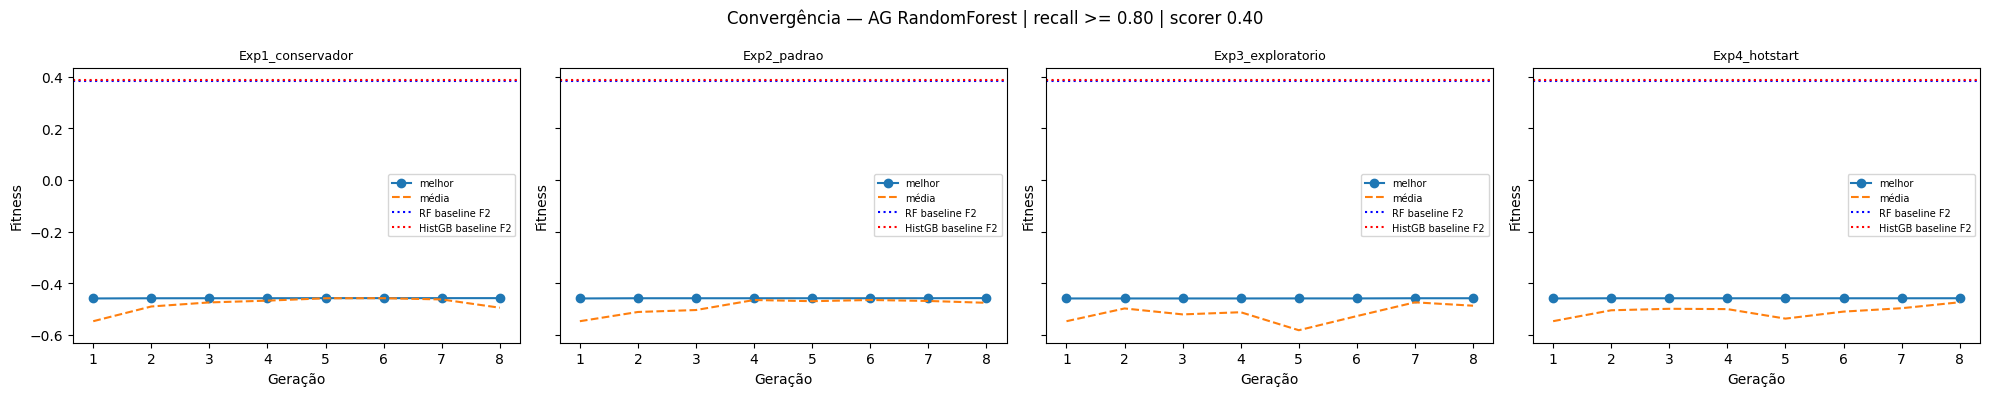

In [14]:
n_exp = len(experiment_results)
fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 4), sharey=True)
for ax, (label, result) in zip(axes, experiment_results.items()):
    h = result['history']
    ax.plot(h['generation'], h['best_fitness'], marker='o', label='melhor')
    ax.plot(h['generation'], h['mean_fitness'], linestyle='--', label='média')
    ax.axhline(rf_baseline_metrics['f2'],    color='blue',  linestyle=':', linewidth=1.5, label='RF baseline F2')
    ax.axhline(histgb_baseline_metrics['f2'], color='red', linestyle=':', linewidth=1.5, label='HistGB baseline F2')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Geração')
    ax.set_ylabel('Fitness')
    ax.legend(fontsize=7)
plt.suptitle('Convergência — AG RandomForest | recall >= 0.80 | scorer 0.40', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_convergence_rf.png', dpi=150)
plt.show()

## Comparativo: RF baseline vs AG-RF vs HistGB baseline

In [15]:
def build_row(label, params, cv_fitness, model_type='rf'):
    m = evaluate_rf_on_test(params) if model_type == 'rf' else evaluate_histgb_on_test(params)
    return {'origem': label, 'modelo': model_type.upper(),
            'cv_fitness': round(cv_fitness, 4), **{k: m[k] for k in METRIC_NAMES}}

rows = [
    build_row('RF baseline (Fase 1)',     RF_BASELINE_PARAMS,    0.0, 'rf'),
    build_row('HistGB baseline (Fase 1)', HISTGB_BASELINE_PARAMS, 0.0, 'histgb'),
    *[
        build_row(lbl, res['best_params'], res['best_cv_fitness'], 'rf')
        for lbl, res in experiment_results.items()
    ]
]

comparison_df = pd.DataFrame(rows).set_index('origem')
print('=== AG-RF vs baselines | threshold 0.40 ===')
display(comparison_df.round(4))
comparison_df.to_csv(METRICS_DIR / '05_comparison_rf.csv')
print(f'Salvo: {METRICS_DIR / "05_comparison_rf.csv"}')
gc.collect()

=== AG-RF vs baselines | threshold 0.40 ===


,modelo,cv_fitness,recall,f2,precision,roc_auc,average_precision,brier
origem,,,,,,,,
RF baseline (Fase 1),RF,0.0000,0.9936,0.3844,0.1113,0.5642,0.1399,0.2450
HistGB baseline (Fase 1),HISTGB,0.0000,0.9743,0.3857,0.1129,0.5773,0.1507,0.2436
Exp1_conservador,RF,-0.4577,1.0000,0.3836,0.1107,0.5540,0.1361,0.2472
Exp2_padrao,RF,-0.4576,1.0000,0.3836,0.1107,0.5541,0.1359,0.2472
Exp3_exploratorio,RF,-0.4582,0.9999,0.3836,0.1107,0.5540,0.1360,0.2472
Exp4_hotstart,RF,-0.4582,0.9999,0.3836,0.1107,0.5540,0.1360,0.2472


Salvo: ../../results/metrics/05e_comparison_rf.csv


175

In [16]:
MAX_FP_GROWTH_PCT = 0.15
MAX_FN_GROWTH_PCT = 0.30
MIN_RECALL_TEST   = 0.80

# Compara contra o RF baseline (justo) e observa vs HistGB (contexto clínico)
rf_base_row    = comparison_df.loc['RF baseline (Fase 1)']
histgb_row     = comparison_df.loc['HistGB baseline (Fase 1)']
ag_rows        = comparison_df.drop(['RF baseline (Fase 1)', 'HistGB baseline (Fase 1)'])
best_exp       = ag_rows.sort_values('f2', ascending=False).iloc[0]
delta_vs_rf    = best_exp['f2'] - rf_base_row['f2']
delta_vs_histgb = best_exp['f2'] - histgb_row['f2']

n_pos        = int(y_test.sum())
fn_base      = int(n_pos * (1 - rf_base_row['recall']))
fn_ag        = int(n_pos * (1 - best_exp['recall']))
tp_base      = n_pos - fn_base
tp_ag        = n_pos - fn_ag
fp_base      = int(tp_base / max(rf_base_row['precision'], 1e-9) - tp_base)
fp_ag        = int(tp_ag   / max(best_exp['precision'],    1e-9) - tp_ag)
fp_growth    = (fp_ag - fp_base) / max(fp_base, 1)
fn_growth    = (fn_ag - fn_base) / max(abs(fn_base), 1)
recall_ok    = best_exp['recall'] >= MIN_RECALL_TEST
fn_ok        = fn_growth <= MAX_FN_GROWTH_PCT
fp_ok        = fp_growth <= MAX_FP_GROWTH_PCT
validacao_ok = recall_ok and fn_ok and fp_ok

print(f'Melhor AG-RF: {best_exp.name}')
print(f'F2        : {best_exp["f2"]:.4f}  (RF base {rf_base_row["f2"]:.4f} | delta {delta_vs_rf:+.4f})')
print(f'              (HistGB base {histgb_row["f2"]:.4f} | delta {delta_vs_histgb:+.4f})')
print(f'Recall    : {best_exp["recall"]:.4f}  (RF base {rf_base_row["recall"]:.4f})')
print(f'ROC-AUC   : {best_exp["roc_auc"]:.4f}  (RF base {rf_base_row["roc_auc"]:.4f} | HistGB {histgb_row["roc_auc"]:.4f})')
print(f'\nFN  RF_base={fn_base:,}  AG-RF={fn_ag:,}  crescimento={fn_growth:+.1%}')
print(f'FP  RF_base={fp_base:,}  AG-RF={fp_ag:,}  crescimento={fp_growth:+.1%}')
print(f'\nValidação clínica (vs RF baseline):')
print(f'  Recall >= {MIN_RECALL_TEST}     : {"OK" if recall_ok else "FALHA"}')
print(f'  FN cresce <= {MAX_FN_GROWTH_PCT:.0%} : {"OK" if fn_ok else "FALHA"}  ({fn_growth:+.1%})')
print(f'  FP cresce <= {MAX_FP_GROWTH_PCT:.0%} : {"OK" if fp_ok else "FALHA"}  ({fp_growth:+.1%})')
print(f'\nAG-RF supera HistGB? {"SIM" if delta_vs_histgb > 0.01 else "Marginal" if delta_vs_histgb > 0 else "NAO"}')
print(f'Pivô: {"APROVADO" if validacao_ok else "REPROVADO"}')

Melhor AG-RF: Exp1_conservador
F2        : 0.3836  (RF base 0.3844 | delta -0.0008)
              (HistGB base 0.3857 | delta -0.0021)
Recall    : 1.0000  (RF base 0.9936)
ROC-AUC   : 0.5540  (RF base 0.5642 | HistGB 0.5773)

FN  RF_base=100  AG-RF=0  crescimento=-100.0%
FP  RF_base=123,446  AG-RF=125,062  crescimento=+1.3%

Validação clínica (vs RF baseline):
  Recall >= 0.8     : OK
  FN cresce <= 30% : OK  (-100.0%)
  FP cresce <= 15% : OK  (+1.3%)

AG-RF supera HistGB? NAO
Pivô: APROVADO
